# Transformada de Hough Estándar (SHT)

El principio fundamental es la conversión de puntos de un espacio cartesiano $(x, y)$ a un espacio de parámetros, permitiendo que el problema de detectar una línea se convierta en un problema de encontrar intersecciones en un acumulador.

**El problema de la pendiente infinita:**

En la ecuación de la recta tradicional $y = mx + c$, una línea vertical tiene una pendiente $m$ infinita, lo que impide su representación computacional. Por ello, se utiliza la notación polar:$$\rho = x \cos \theta + y \sin \theta$$

Donde:

- $\rho$ (rho): Es la distancia perpendicular desde el origen hasta la línea.

- $\theta$ (theta): Es el ángulo formado por esa perpendicular con el eje horizontal.

## El Espacio de Parámetros (Hough Space)

- Punto a Sinusoide: 

   Un punto único en la imagen $(x, y)$ se transforma en una curva sinusoidal en el espacio $(\rho, \theta)$.

- Línea a Punto: 

   Si varios puntos en la imagen pertenecen a la misma recta, todas sus sinusoides en el espacio de Hough se cruzarán en un único punto común $(\rho, \theta)$.

**El Sistema de Votación**

Para implementar esto, el algoritmo crea una matriz bidimensional llamada acumulador.

1. Se discretiza el espacio de $(\rho, \theta)$ en celdas.

2. Para cada píxel de borde detectado (por ejemplo, mediante Canny), se calculan todos los posibles valores de $\rho$ para distintos ángulos $\theta$.

3. Se suma un "voto" a cada celda $(\rho, \theta)$ correspondiente.

4. Las celdas con la mayor cantidad de votos representan las líneas más probables de la imagen original.

Para entender todo esto mejor crearemos un lienzo sintético y aplicaremos Hough:

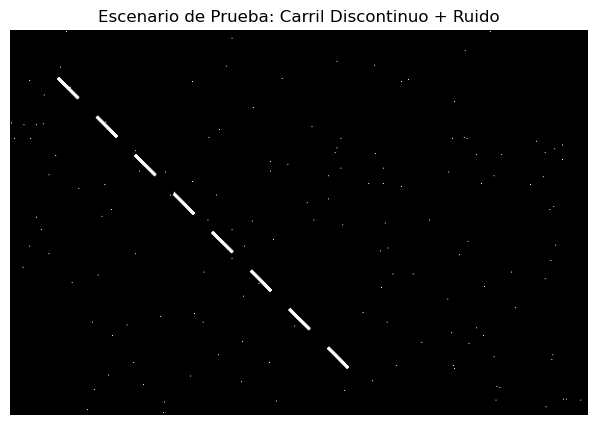

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# 1. Creamos un lienzo negro de 400x600 píxeles
lienzo = np.zeros((400, 600), dtype=np.uint8)

# 2. Dibujamos una línea discontinua (simulando los guiones de un carril)
for i in range(50, 350, 40):
    cv2.line(lienzo, (i, i), (i + 20, i + 20), 255, 2)

# 3. Añadimos ruido aleatorio (simulando reflejos en el asfalto o lluvia)
np.random.seed(42) 
ruido_x = np.random.randint(0, 600, 150)
ruido_y = np.random.randint(0, 400, 150)
lienzo[ruido_y, ruido_x] = 255

# Visualizamos el escenario base
plt.figure(figsize=(8, 5))
plt.imshow(lienzo, cmap='gray')
plt.title("Escenario de Prueba: Carril Discontinuo + Ruido")
plt.axis('off')
plt.show()

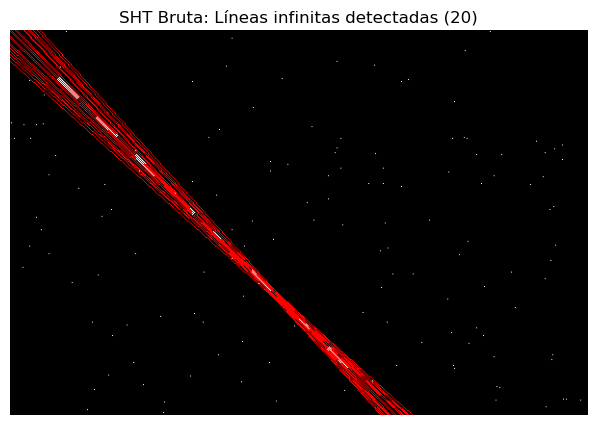

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Parámetros fijos para la visualización estática
umbral_fijo = 35 

# 1. Ejecución de la SHT
lineas = cv2.HoughLines(lienzo, rho=1, theta=np.pi/180, threshold=umbral_fijo)

# Preparación de la imagen de salida
resultado_bruto = cv2.cvtColor(lienzo, cv2.COLOR_GRAY2BGR)

if lineas is not None:
    for i in range(len(lineas)):
        rho, theta = lineas[i][0]
        # Conversión de coordenadas polares a cartesianas para dibujo
        a, b = np.cos(theta), np.sin(theta)
        x0, y0 = a * rho, b * rho
        # Extensión a líneas "infinitas"
        x1 = int(x0 + 1000 * (-b))
        y1 = int(y0 + 1000 * (a))
        x2 = int(x0 - 1000 * (-b))
        y2 = int(y0 - 1000 * (a))
        
        cv2.line(resultado_bruto, (x1, y1), (x2, y2), (255, 0, 0), 1)

# Visualización única
plt.figure(figsize=(8, 5))
plt.imshow(resultado_bruto)
plt.title(f"SHT Bruta: Líneas infinitas detectadas ({len(lineas) if lineas is not None else 0})")
plt.axis('off')
plt.show()

rho=x y theta=y: Definen la resolución del acumulador en el espacio de Hough.

threshold=x: El número mínimo de "votos" o intersecciones para que un conjunto de puntos se considere una línea.

minLineLength=x: Descarta cualquier segmento más corto de x píxeles, eliminando ruidos pequeños.

maxLineGap=x: Permite unir segmentos que están separados por hasta x píxeles, lo cual es vital para detectar líneas de carril discontinuas.

Dentro del bucle for, el código calcula la geometría de cada segmento detectado usando las Ecuaciones 15 y 16 del artículo:

- **Pendiente (slope)**: Se calcula como $m = \frac{y_2 - y_1}{x_2 - x_1}$.

- **Intersección (intercept)**: Se calcula como $c = y_1 - m \cdot x_1$.

**Lógica de filtrado:**

- slope < -0.5: Se clasifica como carril izquierdo. En coordenadas de imagen (donde el origen está arriba a la izquierda), una pendiente negativa indica una línea que se inclina hacia la derecha según sube hacia el horizonte.

- slope > 0.5: Se clasifica como carril derecho.Filtro horizontal: Las líneas con pendientes entre -0.5 y 0.5 se ignoran, ya que suelen ser ruidos del horizonte o sombras transversales.

## Lane Line Averaging

La Transformada de Hough suele detectar decenas de pequeños segmentos para un solo carril debido a discontinuidades en la pintura, sombras o texturas del asfalto. Si dibujáramos todos estos segmentos directamente, la visualización sería caótica y el sistema de control del vehículo recibiría señales contradictorias.

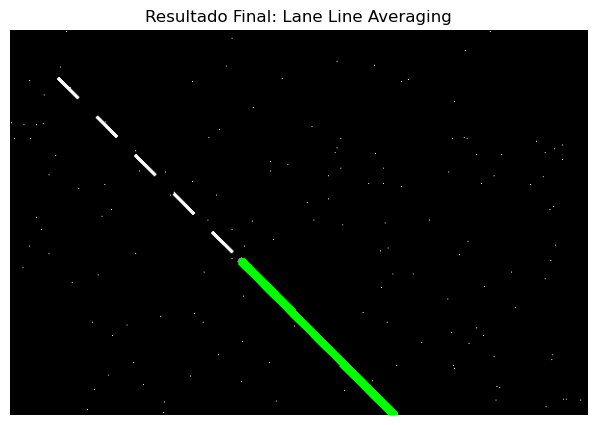

In [28]:
# Listas de parámetros geométricos
pendientes_izq, interceptos_izq = [], []
pendientes_der, interceptos_der = [], []

if lineas is not None:
    for i in range(len(lineas)):
        rho, theta = lineas[i][0]
        sin_t, cos_t = np.sin(theta), np.cos(theta)
        if sin_t == 0: continue
        
        # Ecuaciones de la recta: y = mx + c 
        m = -cos_t / sin_t
        c = rho / sin_t
        
        # Clasificación por signo de pendiente (m < -0.5 Izq, m > 0.5 Der) 
        if m < -0.5:
            pendientes_izq.append(m)
            interceptos_izq.append(c)
        elif m > 0.5:
            pendientes_der.append(m)
            interceptos_der.append(c)

# Dibujo de las líneas maestras promediadas
alto, ancho = lienzo.shape
resultado_final = cv2.cvtColor(lienzo, cv2.COLOR_GRAY2BGR)

for pends, inters in [(pendientes_izq, interceptos_izq), (pendientes_der, interceptos_der)]:
    if pends:
        # Promediado aritmético (Averaging)
        avg_m, avg_c = np.mean(pends), np.mean(inters)
        # Extrapolación (y = mx + c  =>  x = (y - c) / m)
        y1, y2 = alto, int(alto * 0.6)
        x1, x2 = int((y1 - avg_c) / avg_m), int((y2 - avg_c) / avg_m)
        cv2.line(resultado_final, (x1, y1), (x2, y2), (0, 255, 0), 8)

plt.figure(figsize=(8, 5))
plt.imshow(resultado_final)
plt.title("Resultado Final: Lane Line Averaging")
plt.axis('off')
plt.show()

**El Promediado (The Mean)**

Una vez agrupados, se calcula el promedio aritmético de todas las pendientes e interceptos de cada grupo:
$$m_{promedio} = \text{mean}(p_{izq} \text{ o } p_{der})$$
$$c_{promedio} = \text{mean}(c_{izq} \text{ o } c_{der})$$

Este paso es vital porque actúa como un filtro de paso bajo, eliminando el impacto de segmentos "aberrantes" causados por ruido o sombras que tengan pendientes muy diferentes a la media del carril.5. 

**Extrapolación y Dibujo**

Con un solo par de valores $(m, c)$ para cada lado, el sistema puede dibujar líneas continuas que van desde la base de la imagen ($y_{max}$) hasta el horizonte definido ($y_{min}$).

Para encontrar la coordenada $x$ en el horizonte o en la base, se despeja la ecuación: $x = \frac{y - c}{m}$.